In [51]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

data=pd.read_excel('titanic.xls')
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [53]:
#nombre exact de valeurs nulles par collone
data.isna().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [54]:
#supprimer les lignes contenant des valeurs nulles de l'age
data=data.dropna(subset=['age'])
data = data.dropna(subset = ['fare'])
data.isna().sum()

pclass         0
survived       0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
cabin        773
embarked       2
boat         628
body         926
home.dest    360
dtype: int64

In [55]:
#on definis une liste contennat plusiers conditions , et une autre contenant les catégories , grace a l'outil select de numpy on evalue les conditons dans l'ordre 
conditions = [
    (data['fare']<15),
    (data['fare'] >= 15) & (data['fare'] <= 50)
]

categorie = ["Économique", "Standard"]

data['categorie']= np.select(conditions,categorie, default="Luxe")

#supprimons les colones inutilise pour rendre la collone crée plus visible
data=data.drop(["ticket","fare","cabin","embarked","boat","body"], axis = 1)
data


,pclass,survived,name,sex,age,sibsp,parch,home.dest,categorie
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,"St Louis, MO",Luxe
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,"Montreal, PQ / Chesterville, ON",Luxe
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,"Montreal, PQ / Chesterville, ON",Luxe
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,"Montreal, PQ / Chesterville, ON",Luxe
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,"Montreal, PQ / Chesterville, ON",Luxe
...,...,...,...,...,...,...,...,...,...
1301,3,0,"Youseff, Mr. Gerious",male,45.5000,0,0,NaN,Économique
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,NaN,Économique
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,NaN,Économique
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,NaN,Économique


In [56]:
#faisons de meme avec l'age
conditions_a=[
    (data['age']<18),
    (data['age']>=18) & (data['age']<=40)
]

categorie_a=["mineur", "jeune"]

data['maturité'] = np.select(conditions_a,categorie_a, default='vieux')
data

,pclass,survived,name,sex,age,sibsp,parch,home.dest,categorie,maturité
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,"St Louis, MO",Luxe,jeune
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,"Montreal, PQ / Chesterville, ON",Luxe,mineur
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,"Montreal, PQ / Chesterville, ON",Luxe,mineur
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,"Montreal, PQ / Chesterville, ON",Luxe,jeune
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,"Montreal, PQ / Chesterville, ON",Luxe,jeune
...,...,...,...,...,...,...,...,...,...,...
1301,3,0,"Youseff, Mr. Gerious",male,45.5000,0,0,NaN,Économique,vieux
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,NaN,Économique,mineur
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,NaN,Économique,jeune
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,NaN,Économique,jeune


In [57]:
survived=data.groupby(["sex",'maturité']).mean(numeric_only=True)
print(survived)

                   pclass  survived        age     sibsp     parch
sex    maturité                                                   
female jeune     2.079832  0.743697  27.430672  0.483193  0.516807
       mineur    2.527778  0.694444   9.015047  1.152778  1.055556
       vieux     1.512821  0.833333  50.679487  0.525641  0.743590
male   jeune     2.440281  0.185012  27.535129  0.259953  0.152225
       mineur    2.646341  0.378049   9.177845  1.597561  1.060976
       vieux     1.702703  0.168919  51.043919  0.304054  0.209459


In [62]:
sex = data["sex"]
pclass = data["pclass"]
plt.hist(sex,survived,bins=3)
plt.show()

TypeError: hist() got multiple values for argument 'bins'

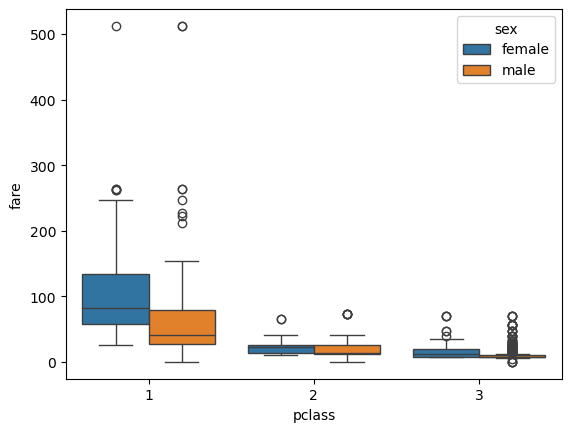

In [61]:
df = sns.load_dataset("titanic")
sns.boxplot(data=df, x='pclass', y='fare', hue='sex')
plt.show()